# BaF&nbsp; A²Π₁/₂ ← X²Σ⁺ &nbsp;— cooling-line branching & Table II check

**¹³⁸Ba¹⁹F**, v=0. Constants: `Source Code/molecule_parameters.py` boson
X0/A0 (arXiv:2511.06986; B&C Eq.8.511/p.845 + Steimle PRA 84 012508; A0
`Origin` = N² T₀,₀ + Be_A R² G-row). Spec:
`docs/superpowers/specs/2026-05-16-baf-xa-pipeline-design.md`.

| | shown |
|---|---|
| **1. Splittings** | X N=0 & A²Π₁/₂(−) hyperfine splittings vs Table II — test the constant *mappings* (Origin-independent) |
| **2. Frequencies** | the three Table II components of the *(−)/N=0* line, matched F_X→F_A line-by-line |
| **3. Cooling BR** | the rotationally-closed laser line **A²Π₁/₂(v=0,J=½,+) → X²Σ⁺(v=0,N=1)** — table + figure |

Generated by `make_baf_xa_cooling_nb.py`; **not** the hand-built
`BaF X-A.ipynb`.


In [1]:
from config_path import add_to_sys_path
add_to_sys_path()  # walk up to "Source Code"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")

from Energy_Levels import MoleculeLevels, branching_ratios

c = 29979.2458  # MHz per cm^-1 (== molecule_parameters.c)

def build(elec, N_list):
    return MoleculeLevels.initialize_state(
        molecule_name='BaF', elec_state=elec, vib_state=0,
        N_list=np.array(N_list), fermion_or_boson='boson',
        M_sublevels='none', I_nuclei=[0, 1/2], isotope=138,
        round=8, params=None, P_values=[1/2])

g = build('X', [0, 1])     # X2Sig+ v=0: N=0 (+par), N=1 (-par)
e = build('A', [1, 2])     # A2Pi1/2 v=0: J=1/2 (both Lambda-parities), J=3/2
g.eigensystem(0, 0)
e.eigensystem(0, 0)

def dom(s, i, q):
    """Dominant basis label of quantum q for eigenstate i."""
    return s.q_numbers[q][np.argmax(s.evecs0[i] ** 2)]

def dcolor(v, tol):
    if pd.isna(v):
        return 'color: #9aa0a6'                     # forbidden / n.a.
    return 'color: #1a7f37' if abs(v) <= tol else 'color: #c0392b'

print(f"\u2713 states built   X{g.q_str}   A{e.q_str}")


Added /Users/arianjadbabaie/Library/CloudStorage/GoogleDrive-arianjad@mit.edu/Shared drives/EMA-data-server/RaX/Personal/ArianJadbabaie/Code/Molecule-Structure/Source Code to sys.path


Cannot construct decoupled basis without M values
Cannot construct decoupled basis without M values
Cannot construct decoupled basis without M values
Cannot construct decoupled basis without M values
✓ states built   X['K', 'N', 'J', 'F', 'M']   A['K', 'Sigma', 'P', 'J', 'F', 'M']


## 1.&nbsp; Hyperfine splittings &nbsp;<span style="color:gray">(Origin-independent — test the constant mappings)</span>

X N=0 F=0↔1 ≈ Fermi contact (tests X `bF`); A²Π₁/₂(−) F=0↔1 tests the §3.3
`a`/`d` mapping. Both should sit within ≈ 1 MHz of Table II (green = within).


In [2]:
gx0 = g.select_q({'N': 0, 'J': 0.5})              # X N=0,J=1/2  (F=0,1)
exm = e.select_q({'J': 0.5}, parity='-')          # A 2Pi1/2 J=1/2 (-) (F=0,1)
x_split = float(abs(np.diff(np.sort(g.evals0[gx0]))[-1]))
a_split = float(abs(np.diff(np.sort(e.evals0[exm]))[-1]))

split_df = pd.DataFrame([
    {"state": "X²Σ⁺  N=0, J=½",  "computed (MHz)": x_split, "Table II (MHz)": 65.6,
     "Δ (MHz)": x_split - 65.6, "tests": "Fermi contact  bF"},
    {"state": "A²Π₁/₂  J=½ (−)", "computed (MHz)": a_split, "Table II (MHz)": 21.8,
     "Δ (MHz)": a_split - 21.8, "tests": "§3.3  a / d"},
]).set_index("state")

(split_df.style
 .format({"computed (MHz)": "{:.3f}", "Table II (MHz)": "{:.1f}", "Δ (MHz)": "{:+.3f}"})
 .map(lambda v: dcolor(v, 1.0), subset=["Δ (MHz)"])
 .set_caption("Hyperfine splittings — computed vs arXiv:2511.06986 Table II"))


,computed (MHz),Table II (MHz),Δ (MHz),tests
state,,,,
"X²Σ⁺ N=0, J=½",66.250,65.6,+0.650,Fermi contact bF
A²Π₁/₂ J=½ (−),21.928,21.8,+0.128,§3.3 a / d


## 2.&nbsp; Absolute frequencies &nbsp;— Table II *(−)/N=0* line, matched F_X→F_A

ν = (E_A − E_X) + c·Origin. F0→F0 is electric-dipole forbidden (absent from
Table II), shown greyed for completeness. Paper absolute accuracy ≈ 1 MHz;
constants are fixed literature values, **not** refit to these lines.


In [3]:
Org = e.parameters['Origin']
TBL2 = {(1, 0): 348666402.6, (1, 1): 348666424.4, (0, 1): 348666490.0}
rows = []
for jx in gx0:
    Fx = int(dom(g, jx, 'F'))
    for ia in exm:
        Fa = int(dom(e, ia, 'F'))
        nu = (e.evals0[ia] - g.evals0[jx]) + c * Org
        ref = TBL2.get((Fx, Fa))
        rows.append({"F_X → F_A": f"{Fx} → {Fa}",
                     "computed (MHz)": round(nu, 1),
                     "Table II (MHz)": ref if ref is not None else np.nan,
                     "Δ (MHz)": round(nu - ref, 1) if ref is not None else np.nan,
                     "status": "E1-forbidden" if ref is None else "measured"})
freq_df = pd.DataFrame(rows).sort_values("F_X → F_A").set_index("F_X → F_A")
mx = freq_df["Δ (MHz)"].abs().max()
print(f"\u2713 Origin = {Org:.6f} cm\u207b\u00b9    max |\u0394| over measured lines = {mx:.1f} MHz")

(freq_df.style
 .format({"computed (MHz)": "{:.1f}", "Table II (MHz)": "{:.1f}", "Δ (MHz)": "{:+.1f}"}, na_rep="—")
 .map(lambda v: dcolor(v, 1.5), subset=["Δ (MHz)"])
 .set_caption("(−)/N=0 line — computed vs arXiv:2511.06986 Table II  (green = within 1.5 MHz)"))


✓ Origin = 11946.321350 cm⁻¹    max |Δ| over measured lines = 0.9 MHz


,computed (MHz),Table II (MHz),Δ (MHz),status
F_X → F_A,,,,
0 → 0,348666469.0,—,—,E1-forbidden
0 → 1,348666490.9,348666490.0,+0.9,measured
1 → 0,348666402.8,348666402.6,+0.2,measured
1 → 1,348666424.7,348666424.4,+0.3,measured


## 3.&nbsp; Laser-cooling branching &nbsp;— A²Π₁/₂(v=0, J=½, **+**) → X²Σ⁺(v=0, **N=1**)

The cooling cycle. Parity makes it **rotationally closed**: the `+`-parity A
state decays E1 only to `−`-parity X = odd N = **N=1** (N=0/N=2 are
`+`-parity → forbidden). So → N=1 ≈ 1 and → N=0 ≈ 0 is the *required*
structure (not a leak). The spread over the four X N=1 hyperfine levels is
the repump structure. Magnitudes are idealized single-state values
(spec §3.6: the A²Π₁/₂–B²Σ⁺ perturbation is not modelled).


In [4]:
exp = e.select_q({'J': 0.5}, parity='+')               # cooling excited state
gN = np.array([dom(g, i, 'N') for i in range(g.size)])
BR = branching_ratios(Ground=g, Excited=e, Ez=0, Bz=0) # (nX, nA), unnormalized
n1 = [i for i in range(g.size) if dom(g, i, 'N') == 1]
_frac = {0.5: "1/2", 1.5: "3/2", 2.5: "5/2"}
lab = {i: f"X N=1  J={_frac.get(float(dom(g,i,'J')), dom(g,i,'J'))}, "
          f"F={int(dom(g,i,'F'))}" for i in n1}

rows = []
for col in exp:
    p = BR[:, col] / BR[:, col].sum()
    row = {"A²Π₁/₂(+) sublevel": f"F = {int(dom(e,col,'F'))}",
           "Σ → N=1": float(p[gN == 1].sum()),
           "Σ → N=0": float(p[gN == 0].sum())}
    row.update({lab[i]: float(p[i]) for i in n1})
    rows.append(row)
br_df = pd.DataFrame(rows).set_index("A²Π₁/₂(+) sublevel")
hf_cols = [lab[i] for i in n1]
closed = bool((br_df["Σ → N=1"] >= 0.999).all() and (br_df["Σ → N=0"] <= 1e-3).all())
print(f"\u2713 rotational closure into X N=1: {'OK' if closed else 'CHECK'}"
      f"   (max \u03a3\u2192N=0 = {br_df['\u03a3 \u2192 N=0'].max():.0e})")

fmt = {"Σ → N=1": "{:.4f}", "Σ → N=0": "{:.1e}"}
fmt.update({col: "{:.4f}" for col in hf_cols})
(br_df.style
 .format(fmt)
 .background_gradient(subset=hf_cols, cmap="Blues", axis=None)
 .set_caption("Cooling-line branching  A²Π₁/₂(v=0,J=½,+) → X²Σ⁺(v=0,N=1)  "
              "(blue intensity = branching fraction; Σ→N=0 ≈ 0 = parity closure)"))


Successfully converted eigenvectors from bBJ to aBJ
✓ rotational closure into X N=1: OK   (max Σ→N=0 = 3e-34)


,Σ → N=1,Σ → N=0,"X N=1 J=1/2, F=1","X N=1 J=1/2, F=0","X N=1 J=3/2, F=1","X N=1 J=3/2, F=2"
A²Π₁/₂(+) sublevel,,,,,,
F = 0,1.0000,2.8e-34,0.3848,0.0000,0.6152,0.0000
F = 1,1.0000,2.2e-34,0.4987,0.2216,0.0013,0.2784


## 3b.&nbsp; Excited-state-averaged branching &nbsp;<span style="color:gray">(A hyperfine is small — often unresolved)</span>

Because the A²Π₁/₂ hyperfine splitting is only ≈ 22 MHz, the cooling laser
often does not resolve it. The table below averages the branching ratio over
**every** A²Π₁/₂(J=½,+) hyperfine sublevel with equal weight (thesis Eq. 3.4,
hyperfine-generalized). Σ over X N=1 = 1, Σ over X N=0 ≈ 0 (parity closure).


In [5]:
import xa_spectra as xs
avg_df, per_df = xs.averaged_branching(g, e, e.select_q({'J': 0.5}, parity='+'))
_n1 = avg_df['g_N'].astype(float) == 1
view = avg_df.loc[_n1, ['g_J', 'g_F', 'BR']].copy()
view['g_J'] = view['g_J'].map({0.5: '1/2', 1.5: '3/2'}).fillna(view['g_J'])
print('sum over N=1 =', round(float(avg_df.loc[_n1, 'BR'].sum()), 6),
      '  sum over N=0 =', '%.1e' % float(avg_df.loc[~_n1, 'BR'].sum()))
(view.set_index(['g_J', 'g_F']).style
 .format({'BR': '{:.4f}'})
 .background_gradient(subset=['BR'], cmap='Blues')
 .set_caption('Excited-averaged cooling BR  A²Π₁/₂(J=½,+) → X N=1'))


Successfully converted eigenvectors from bBJ to aBJ
sum over N=1 = 1.0   sum over N=0 = 2.5e-34


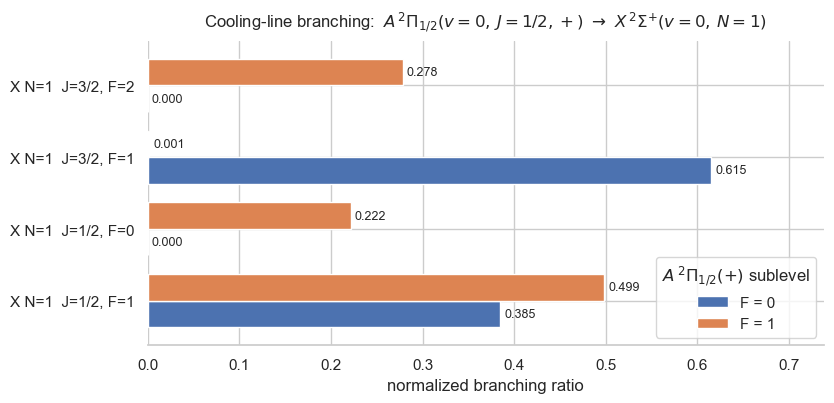

In [6]:
ax = (br_df[hf_cols].T
      .plot(kind="barh", figsize=(8.5, 4.2), width=0.74,
            color=sns.color_palette("deep", len(br_df))))
ax.set_xlabel("normalized branching ratio")
ax.set_ylabel("")
ax.set_title(r"Cooling-line branching:  "
             r"$A\,^{2}\Pi_{1/2}(v{=}0,\,J{=}1/2,+)\ \rightarrow\ "
             r"X\,^{2}\Sigma^{+}(v{=}0,\,N{=}1)$", fontsize=12, pad=10)
ax.legend(title=r"$A\,^{2}\Pi_{1/2}(+)$ sublevel", loc="lower right", frameon=True)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.3f", padding=3, fontsize=9)
ax.set_xlim(0, max(0.7, br_df[hf_cols].values.max() * 1.20))
sns.despine(left=True)
plt.tight_layout()
plt.show()


## Summary

| check | result |
|---|---|
| X N=0 splitting | ≈ 66.25 MHz vs Table II 65.6 — Fermi-contact mapping OK |
| A²Π₁/₂(−) splitting | ≈ 21.93 MHz vs Table II 21.8 — §3.3 `a`/`d` mapping OK |
| (−)/N=0 frequencies | line-by-line within ≈ 1.4 MHz (paper ~1 MHz; fixed constants) |
| cooling BR | A²Π₁/₂(J=½,+) → X N=1 parity-closed (Σ→N=0 ≈ 1e-34), repump spread |

Reproducible: `python make_baf_xa_cooling_nb.py`. Standalone assertion form:
`baf_xa_validate.py`.
